In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# left skewed data 
ages = [40, 45, 50, 55, 60, 60, 62, 63, 64, 65, 65, 65, 66, 67, 68 , 69,69 , 70]
ages = pd.Series(ages,name='age')
# for left skewed data mean < median < mode

print('mean - ',np.mean(ages))
print('median - ', np.median(ages))
print("mode - ", ages.mode()[0])

mean -  61.27777777777778
median -  64.5
mode -  65


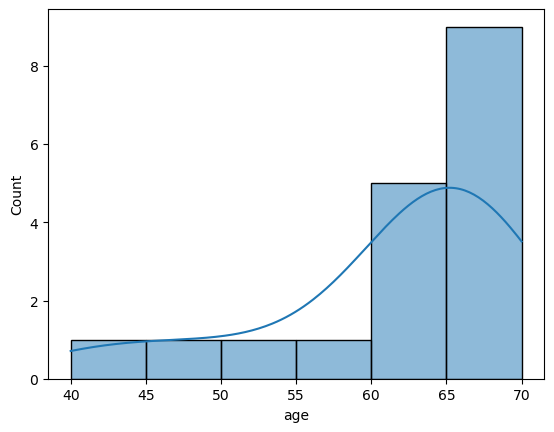

In [3]:
sns.histplot(x= ages , kde = True)
plt.show()

In [4]:
# right skewed data

right_skewed_data = pd.Series([1, 2, 2, 3, 3, 3, 4, 4, 5, 6, 8, 10, 15, 20, 35, 50])

# for left skewed data mean > median > mode

print('mean - ',np.mean(right_skewed_data))
print('median - ', np.median(right_skewed_data))
print("mode - ", right_skewed_data.mode()[0])

mean -  10.6875
median -  4.5
mode -  3


<Axes: ylabel='Count'>

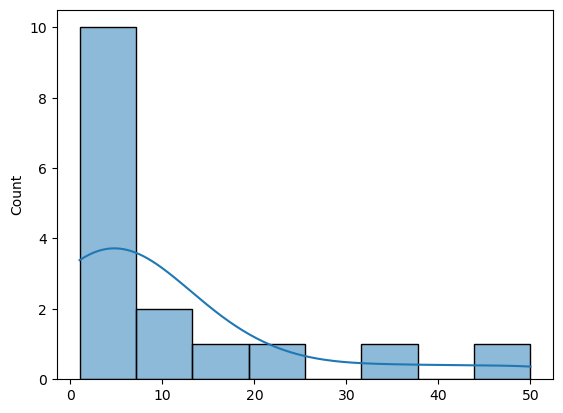

In [5]:
sns.histplot(right_skewed_data , kde=True)

In [6]:
# symmetric skewness

data = pd.Series([1,2,3,4,4,4,5,5,5,5,6,6,6,7,8,9])
# for left skewed data mean = median = mode

print('mean - ',np.mean(data))
print('median - ', np.median(data))
print("mode - ", data.mode()[0])

mean -  5.0
median -  5.0
mode -  5


<Axes: ylabel='Count'>

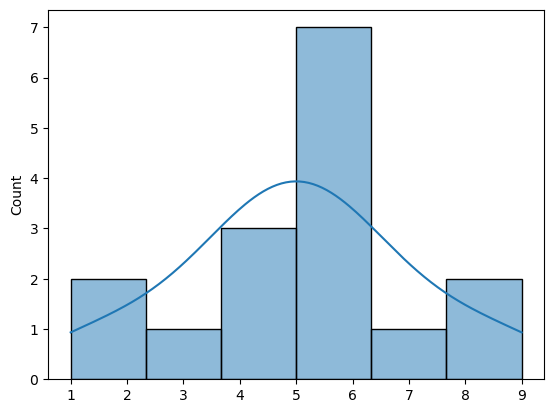

In [7]:
sns.histplot(data , kde = True)

### types of skewness
1. moment based skewness
2. pearson's skewness
3. bowley's skewness


### moment based skewness

$$
\frac{1}{N}\times \Sigma \left(\frac{x_i - \bar \mu}{\sigma}\right)^3
$$

In [8]:
def calculate_skewness(data) :
    skewness = ((data - np.mean(data))/np.std(data))**3
    sk = skewness.sum() / len(data)
    print('skewness result - ',sk)
    return 

In [12]:
# moment based skewness

calculate_skewness(data)
# output = 0 --> so zero skewness(normal distribution) --> most of the data is on middle

calculate_skewness(ages)
# output = -ve --> left skewed (-ve skewness)  --> most of the data on right

calculate_skewness(right_skewed_data)
# output = +ve --> right skewed (+ve skewness) --> most of the data on left


skewness result -  0.0
skewness result -  -1.2963408728485941
skewness result -  1.9151858660625078


### pearson's skewness
with mode -  
$$
\frac{mean-mode}{std}
$$

with median -  
$$
\frac{3(mean-median)}{std}
$$

In [16]:
# pearson's skewness

def calculate_pearson_skewness_with_mode(data) :
    sk = (np.mean(data) - data.mode()[0])/np.std(data)
    print('pearson skewness using mode - ',sk)
    
# when mode is not reliable
def calculate_pearson_skewness_with_median(data) :
    sk = 3*(np.mean(data) - np.median(data))/np.std(data)
    print('pearson skewness using median - ',sk)

In [20]:
# no skewed 
calculate_pearson_skewness_with_mode(data)
calculate_pearson_skewness_with_median(data)

# left skewed 
calculate_pearson_skewness_with_mode(ages)
calculate_pearson_skewness_with_median(ages)

# right skewed 
calculate_pearson_skewness_with_mode(right_skewed_data)
calculate_pearson_skewness_with_median(right_skewed_data)

pearson skewness using mode -  0.0
pearson skewness using median -  0.0
pearson skewness using mode -  -0.44925989125431953
pearson skewness using median -  -1.1667346429589789
pearson skewness using mode -  0.5795249987219465
pearson skewness using median -  1.3993408505725051


### bowley's skewness
$$
\frac{Q3+Q1-2Q2}{Q2-Q1}
$$

In [21]:
def calculate_bowleys_skewness(data):
    Q1 = np.percentile(data, 25)
    Q2 = np.percentile(data, 50)
    Q3 = np.percentile(data, 75)
    sk = (Q3 + Q1 - 2 * Q2)/(Q2 - Q1)
    print('bowleys skewness - ',sk)

In [22]:
# no skewed 
calculate_bowleys_skewness(data)

# left skewed 
calculate_bowleys_skewness(ages)

# right skewed 
calculate_bowleys_skewness(right_skewed_data)

bowleys skewness -  0.0
bowleys skewness -  -0.5
bowleys skewness -  3.5


### kurtosis 
- mesokurtic (k=3)
- Leptokurtic (k > 3)  --> more outliers
- Platokurtic (k < 3)  --> fewer outliers

In [49]:
def calculate_kurtosis(data) :
    k = (((data - np.mean(data))/np.std(data)) ** 4)
    kurtosis = ((1/len(data)) * np.sum(k)) -3 
    print("kurtosis is ",kurtosis)
    if kurtosis > 3 :
        print("Leptokurtic")
    elif kurtosis < 3:
        print("Platokurtic")
    else:
        print("Mesokurtic")

In [55]:
import scipy.stats as stats
calculate_kurtosis(data)
print(stats.kurtosis(data , bias=True))
print(data.kurt())
print(stats.kurtosis(data , bias=False))

kurtosis is  -0.21875
Platokurtic
-0.21875
0.18801510989010994
0.18801510989010994
